# Camada Gold — Análise de Viagens a Serviço

Pipeline: Portal da Transparência (Viagens a Serviço, 2025 jan-jun).

Este notebook responde **6 perguntas de negócio**:
- **3 direto da camada Silver** (consultas simples, uma tabela por vez)
- **3 usando a camada Gold** (tabela agregada criada via JOIN + GROUP BY, também disponível como VIEW)

**Premissa de negócio assumida:** uma viagem pode ter vários trechos (ida, escalas, volta),
cada um com um destino diferente. Para não contar o custo da viagem várias vezes (uma vez
por trecho), definimos o **destino principal da viagem** como o destino do **primeiro trecho**
(`sequencia_trecho` mais baixa). Isso evita duplicar custo quando agregamos por destino.


## 1. Conexão com o banco

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from banco import conectar

sns.set_theme(style="whitegrid")
conexao = conectar()
print("Conectado com sucesso.")


Conectado com sucesso.


## 2. Perguntas de negócio — Camada Silver

Consultas diretas em uma única tabela Silver por vez (sem JOIN).

### 2.1 Os 5 órgãos com maior custo total

In [36]:
sql_q1 = """
    SELECT nome_orgao_superior,
           SUM(valor_total) AS custo_total
    FROM silver_viagem
    GROUP BY nome_orgao_superior
    ORDER BY custo_total DESC
    LIMIT 5
"""
df_q1 = pd.read_sql(sql_q1, conexao)
df_q1


C:\Users\Nayh\AppData\Local\Temp\ipykernel_17896\2657990883.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q1 = pd.read_sql(sql_q1, conexao)


,nome_orgao_superior,custo_total
0,Ministério da Justiça e Segurança Pública,4.869331e+08
1,Ministério da Defesa,1.560703e+08
2,Ministério da Educação,1.112913e+08
3,Ministério do Meio Ambiente e Mudança do Clima,4.969771e+07
4,Ministério da Previdência Social,4.041731e+07


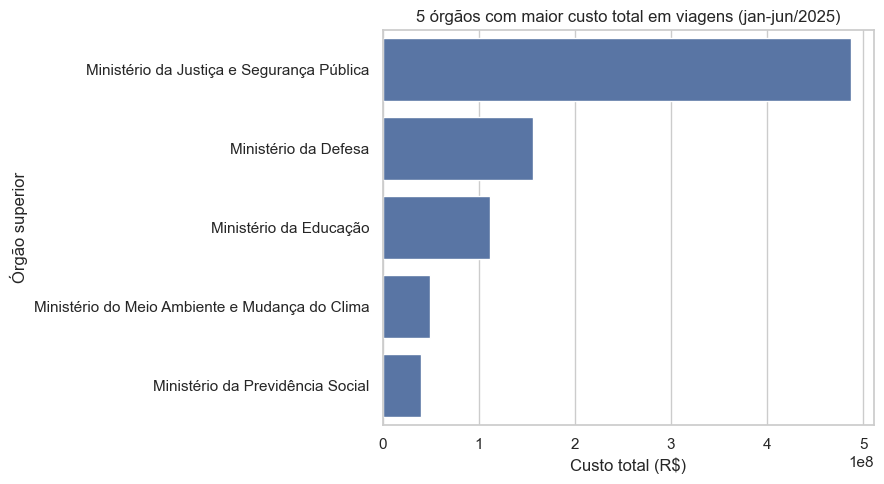

In [37]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=df_q1, y="nome_orgao_superior", x="custo_total", ax=ax, color="#4C72B0")
ax.set_title("5 órgãos com maior custo total em viagens (jan-jun/2025)")
ax.set_xlabel("Custo total (R$)")
ax.set_ylabel("Órgão superior")
plt.tight_layout()
plt.show()


### 2.2 A viagem de maior duração e seu custo total

In [38]:
sql_q2 = """
    SELECT id_viagem, nome_viajante, nome_orgao_superior,
           data_inicio, data_fim, duracao_dias, valor_total
    FROM silver_viagem
    ORDER BY duracao_dias DESC
    LIMIT 10
"""
df_q2 = pd.read_sql(sql_q2, conexao)
print("Viagem de maior duração:")
df_q2.head(1)


C:\Users\Nayh\AppData\Local\Temp\ipykernel_17896\2524685865.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q2 = pd.read_sql(sql_q2, conexao)


Viagem de maior duração:


,id_viagem,nome_viajante,nome_orgao_superior,data_inicio,data_fim,duracao_dias,valor_total
0,0000000000020699856,LUISANGELA CORREA FRANCO DE FARIA,Ministério da Previdência Social,2025-01-13,2026-01-31,384,0.0


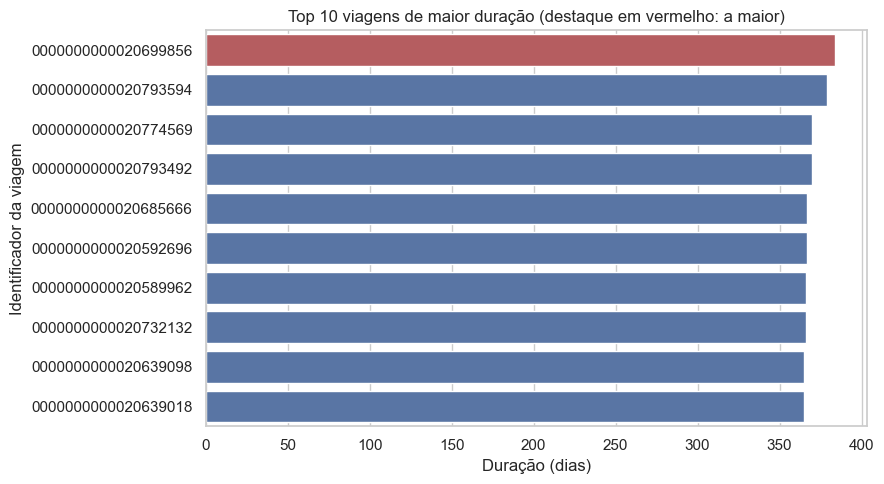

In [39]:
fig, ax = plt.subplots(figsize=(9, 5))
cores = ["#C44E52" if i == 0 else "#4C72B0" for i in range(len(df_q2))]
sns.barplot(data=df_q2, y="id_viagem", x="duracao_dias", ax=ax, palette=cores, hue="id_viagem", legend=False)
ax.set_title("Top 10 viagens de maior duração (destaque em vermelho: a maior)")
ax.set_xlabel("Duração (dias)")
ax.set_ylabel("Identificador da viagem")
plt.tight_layout()
plt.show()


### 2.3 Qual o tipo de pagamento com maior valor médio

In [40]:
sql_q3 = """
    SELECT tipo_pagamento,
           COUNT(*) AS qtd_pagamentos,
           ROUND(AVG(valor), 2) AS valor_medio
    FROM silver_pagamento
    GROUP BY tipo_pagamento
    ORDER BY valor_medio DESC
"""
df_q3 = pd.read_sql(sql_q3, conexao)
df_q3


C:\Users\Nayh\AppData\Local\Temp\ipykernel_17896\1309241055.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q3 = pd.read_sql(sql_q3, conexao)


,tipo_pagamento,qtd_pagamentos,valor_medio
0,DIÁRIAS,401463,2078.28
1,PASSAGEM,188985,1878.34
2,Serviço correlato: seguro,4894,447.51
3,RESTITUIÇÃO,11574,245.70


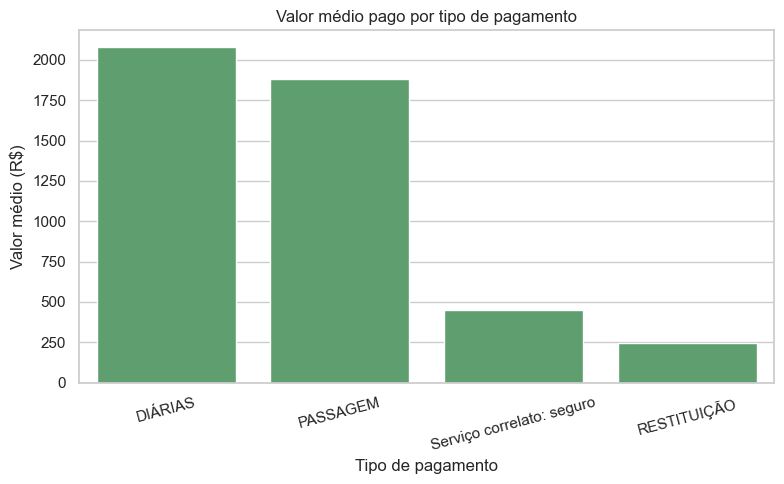

In [41]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_q3, x="tipo_pagamento", y="valor_medio", ax=ax, color="#55A868")
ax.set_title("Valor médio pago por tipo de pagamento")
ax.set_xlabel("Tipo de pagamento")
ax.set_ylabel("Valor médio (R$)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 3. Camada Gold — tabela agregada (JOIN + GROUP BY)

Criamos `gold_destino_uf`, agregada por UF de destino, combinando:
- **silver_viagem** (custo da viagem)
- **silver_trecho** (destino principal = primeiro trecho da viagem, e contagem de trechos)

Criada tanto como **VIEW** (`view_gold_destino_uf`) quanto como **TABELA** (`gold_destino_uf`),
conforme pedido no enunciado.

In [42]:
sql_criar_gold = """
DROP VIEW IF EXISTS view_gold_destino_uf CASCADE;
DROP TABLE IF EXISTS gold_destino_uf;

CREATE VIEW view_gold_destino_uf AS
WITH primeiro_trecho AS (
    -- destino principal da viagem = destino do primeiro trecho (evita duplicar custo)
    SELECT DISTINCT ON (id_viagem) id_viagem, destino_uf AS destino_principal
    FROM silver_trecho
    WHERE destino_uf IS NOT NULL AND destino_uf <> 'Inválido'
    ORDER BY id_viagem, sequencia_trecho
),
custo_por_destino AS (
    SELECT pt.destino_principal AS destino_uf,
           COUNT(DISTINCT v.id_viagem) AS qtd_viagens,
           SUM(v.valor_total)          AS custo_total,
           ROUND(AVG(v.valor_total), 2) AS custo_medio_viagem
    FROM silver_viagem v
    JOIN primeiro_trecho pt ON pt.id_viagem = v.id_viagem
    GROUP BY pt.destino_principal
),
trechos_por_destino AS (
    -- todos os trechos (nao so o primeiro), para contar onde ha mais movimento
    SELECT destino_uf, COUNT(*) AS qtd_trechos
    FROM silver_trecho
    WHERE destino_uf IS NOT NULL
    GROUP BY destino_uf
)
SELECT
    c.destino_uf,
    c.qtd_viagens,
    c.custo_total,
    c.custo_medio_viagem,
    COALESCE(t.qtd_trechos, 0) AS qtd_trechos
FROM custo_por_destino c
LEFT JOIN trechos_por_destino t ON t.destino_uf = c.destino_uf
ORDER BY c.destino_uf;

CREATE TABLE gold_destino_uf AS
SELECT * FROM view_gold_destino_uf;
"""

cursor = conexao.cursor()
cursor.execute(sql_criar_gold)
conexao.commit()
cursor.close()
print("gold_destino_uf (tabela) e view_gold_destino_uf (view) criadas com sucesso.")


gold_destino_uf (tabela) e view_gold_destino_uf (view) criadas com sucesso.


In [43]:
df_gold = pd.read_sql("SELECT * FROM gold_destino_uf ORDER BY custo_total DESC", conexao)
df_gold.head(10)


C:\Users\Nayh\AppData\Local\Temp\ipykernel_17896\2900404328.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_gold = pd.read_sql("SELECT * FROM gold_destino_uf ORDER BY custo_total DESC", conexao)


,destino_uf,qtd_viagens,custo_total,custo_medio_viagem,qtd_trechos
0,Distrito Federal,29624,3.007783e+08,10153.20,79962
1,São Paulo,37198,9.464886e+07,2544.46,82722
2,Rio de Janeiro,17890,6.862745e+07,3836.08,44197
3,Pará,13785,5.732330e+07,4158.38,40044
4,Roraima,6445,4.810870e+07,7464.50,18778
5,Paraná,16345,4.400611e+07,2692.33,42603
6,Amazonas,9358,4.047681e+07,4325.37,26477
7,Rio Grande do Sul,15386,3.253974e+07,2114.89,38684
8,Minas Gerais,20587,3.103800e+07,1507.65,50965
9,Mato Grosso do Sul,10542,2.464189e+07,2337.50,30516


### 3.1 Os 3 destinos (UF) com maior custo médio por viagem

In [44]:
df_g1 = df_gold.sort_values("custo_medio_viagem", ascending=False).head(3)
df_g1


,destino_uf,qtd_viagens,custo_total,custo_medio_viagem,qtd_trechos
0,Distrito Federal,29624,3.007783e+08,10153.20,79962
4,Roraima,6445,4.810870e+07,7464.50,18778
6,Amazonas,9358,4.047681e+07,4325.37,26477


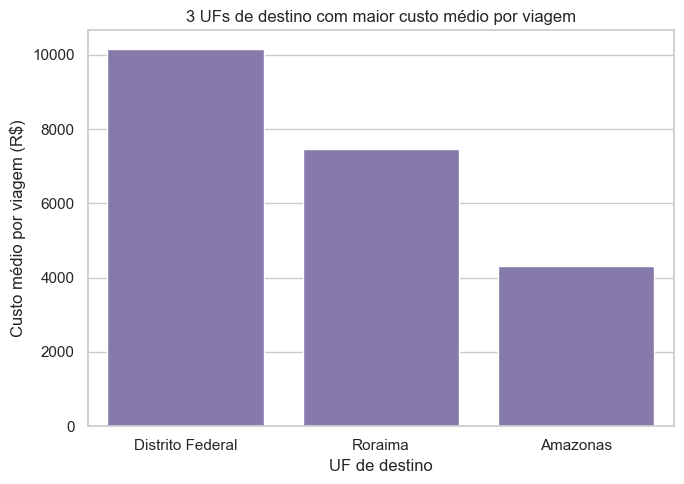

In [45]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=df_g1, x="destino_uf", y="custo_medio_viagem", ax=ax, color="#8172B2")
ax.set_title("3 UFs de destino com maior custo médio por viagem")
ax.set_xlabel("UF de destino")
ax.set_ylabel("Custo médio por viagem (R$)")
plt.tight_layout()
plt.show()


### 3.2 Qual UF de destino aparece em mais trechos

In [46]:
df_g2 = df_gold.sort_values("qtd_trechos", ascending=False).head(10)
print("UF com mais trechos:", df_g2.iloc[0]["destino_uf"], "-", int(df_g2.iloc[0]["qtd_trechos"]), "trechos")
df_g2


UF com mais trechos: São Paulo - 82722 trechos


,destino_uf,qtd_viagens,custo_total,custo_medio_viagem,qtd_trechos
1,São Paulo,37198,9.464886e+07,2544.46,82722
0,Distrito Federal,29624,3.007783e+08,10153.20,79962
8,Minas Gerais,20587,3.103800e+07,1507.65,50965
2,Rio de Janeiro,17890,6.862745e+07,3836.08,44197
5,Paraná,16345,4.400611e+07,2692.33,42603
3,Pará,13785,5.732330e+07,4158.38,40044
7,Rio Grande do Sul,15386,3.253974e+07,2114.89,38684
9,Mato Grosso do Sul,10542,2.464189e+07,2337.50,30516
10,Bahia,11114,2.295041e+07,2065.00,28375
12,Pernambuco,10183,2.126918e+07,2088.70,28372


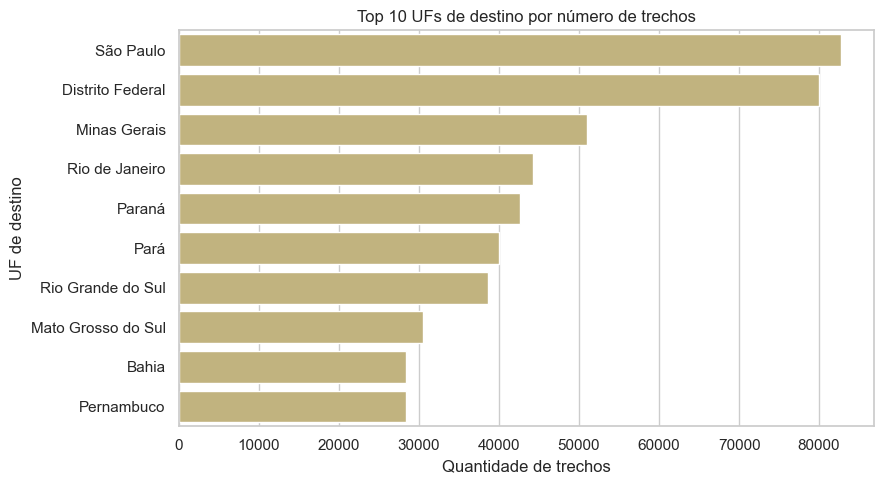

In [47]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=df_g2, y="destino_uf", x="qtd_trechos", ax=ax, color="#CCB974")
ax.set_title("Top 10 UFs de destino por número de trechos")
ax.set_xlabel("Quantidade de trechos")
ax.set_ylabel("UF de destino")
plt.tight_layout()
plt.show()


### 3.3 Qual órgão pagou mais no total

In [48]:
sql_g3 = """
    SELECT v.nome_orgao_superior,
           SUM(p.valor) AS valor_total_pago
    FROM silver_viagem v
    JOIN silver_pagamento p ON p.id_viagem = v.id_viagem
    GROUP BY v.nome_orgao_superior
    ORDER BY valor_total_pago DESC
    LIMIT 5
"""
df_g3 = pd.read_sql(sql_g3, conexao)
df_g3


C:\Users\Nayh\AppData\Local\Temp\ipykernel_17896\1689398958.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_g3 = pd.read_sql(sql_g3, conexao)


,nome_orgao_superior,valor_total_pago
0,Ministério da Justiça e Segurança Pública,4.888311e+08
1,Ministério da Defesa,1.565498e+08
2,Ministério da Educação,1.118974e+08
3,Ministério do Meio Ambiente e Mudança do Clima,5.012304e+07
4,Ministério da Previdência Social,4.065949e+07


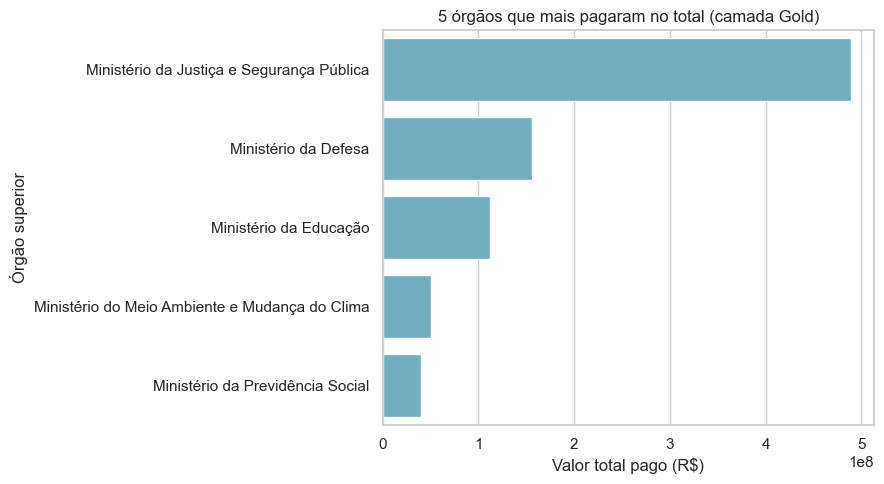

In [49]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=df_g3, y="nome_orgao_superior", x="valor_total_pago", ax=ax, color="#64B5CD")
ax.set_title("5 órgãos que mais pagaram no total (camada Gold)")
ax.set_xlabel("Valor total pago (R$)")
ax.set_ylabel("Órgão superior")
plt.tight_layout()
plt.show()


### 3.4 (Bônus) Qual o meio de transporte mais usado nos trechos

In [50]:
sql_q5 = """
    SELECT meio_transporte, COUNT(*) AS qtd_trechos
    FROM silver_trecho
    WHERE meio_transporte IS NOT NULL AND meio_transporte <> 'Inválido'
    GROUP BY meio_transporte
    ORDER BY qtd_trechos DESC
"""
df_q5 = pd.read_sql(sql_q5, conexao)
df_q5


C:\Users\Nayh\AppData\Local\Temp\ipykernel_17896\2642364163.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q5 = pd.read_sql(sql_q5, conexao)


,meio_transporte,qtd_trechos
0,Veículo Oficial,386424
1,Aéreo,232666
2,Rodoviário,64970
3,Veículo Próprio,42846
4,Fluvial,8429
5,Ferroviário,874
6,Marítimo,481


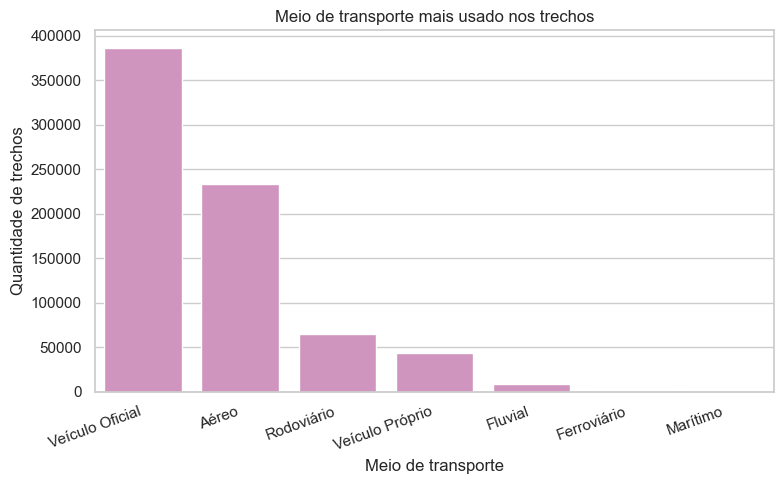

In [51]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_q5, x="meio_transporte", y="qtd_trechos", ax=ax, color="#DA8BC3")
ax.set_title("Meio de transporte mais usado nos trechos")
ax.set_xlabel("Meio de transporte")
ax.set_ylabel("Quantidade de trechos")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## 4. Conclusões

### Respostas às 7 perguntas de negócio

**1. Os 5 órgãos com maior custo total:**
1. Ministério da Justiça e Segurança Pública — R$ 486.933.121,65
2. Ministério da Defesa — R$ 156.070.304,49
3. Ministério da Educação — R$ 111.291.349,34
4. Ministério do Meio Ambiente e Mudança do Clima — R$ 49.697.710,16
5. Ministério da Previdência Social — R$ 40.417.309,06

O Ministério da Justiça e Segurança Pública gastou **mais que os outros 4 juntos**, cerca
de 3x o segundo colocado (Defesa).

**2. Os 3 destinos (UF) com maior custo médio por viagem** (considerando o destino do
primeiro trecho de cada viagem, e excluindo o valor "Inválido" presente na base bruta):
1. Distrito Federal — R$ 10.153,20 em média por viagem (29.624 viagens)
2. Roraima — R$ 7.464,50 em média (6.445 viagens)
3. Amazonas — R$ 4.325,37 em média (9.358 viagens)

Os destinos mais caros em média são justamente o DF (concentração de órgãos/decisões em
Brasília) e destinos na região Norte (RR, AM) — condizente com o alto custo logístico de
chegar a essas regiões.

**3. A viagem de maior duração e seu custo total:**
Viagem `0000000000020699856`, de Luisangela Correa Franco de Faria (Ministério da
Previdência Social), com **384 dias de duração** (13/01/2025 a 31/01/2026) e **custo
total de R$ 0,00**. O motivo registrado foi a convocação da servidora para atuação
presencial em outra unidade (Mogi Mirim) — ou seja, não é uma "viagem" no sentido
tradicional (com diárias e passagens), e sim uma **relotação/cessão de longo prazo**
registrada no mesmo sistema. Conferimos os valores brutos na fonte (Portal da Transparência) 
e confirmamos que o próprio CSV original já traz R$ 0,00 em todos os campos de valor, 
não é um erro de cálculo do pipeline.

**4. Tipo de pagamento com maior valor médio:**
**Diárias** — R$ 2.078,28 em média (401.463 pagamentos), levemente à frente de
Passagem (R$ 1.878,34, 188.985 pagamentos). Restituição e "Serviço correlato: seguro"
têm valores médios bem menores.

**5. Meio de transporte mais usado nos trechos** (bônus, excluindo o valor "Inválido"):
**Veículo Oficial** — 386.424 trechos, à frente de Aéreo (232.666) e Rodoviário (64.970).
Isso mostra que a maior parte da movimentação registrada é local/regional com carro
oficial, não viagens aéreas de longa distância.

**6. UF de destino que aparece em mais trechos:**
**São Paulo** — 82.722 trechos, seguida de perto por Distrito Federal (79.962) e
Minas Gerais (50.965).

**7. Órgão que pagou mais no total:**
**Ministério da Justiça e Segurança Pública** — R$ 488.831.110,61, confirmando (via a
tabela `silver_pagamento`, de forma independente) o mesmo órgão identificado na
pergunta 1. Os dois valores (R$ 486,9 milhões pela ótica de `valor_total` da viagem e
R$ 488,8 milhões pela ótica da soma de pagamentos) são muito próximos — a pequena
diferença é esperada, já que nem todo pagamento registrado corresponde exatamente ao
`valor_total` calculado da viagem (podem existir pagamentos complementares ou parciais).

### Insights gerais

- **Concentração de gastos:** um único órgão (Justiça e Segurança Pública) responde por
  quase metade do gasto total do semestre — vale investigar se isso reflete uma operação
  específica (ex.: reforço de segurança em grandes eventos) ou é um padrão constante ao
  longo do ano.
- **Consistência dos dados:** o ranking de órgãos por custo bate entre duas fontes
  diferentes (`valor_total` da viagem vs. soma de `valor` em pagamentos), o que dá
  confiança na qualidade da transformação Raw → Silver.
- **Qualidade dos dados de origem:** a base trouxe valores como "Inválido" em campos de
  UF e meio de transporte — provavelmente registros com preenchimento incompleto no
  sistema de origem. Tratamos isso filtrando esses valores das agregações de negócio,
  mas vale registrar como limitação conhecida da fonte.
- **Padrão de deslocamento:** a maior parte da movimentação é feita em veículo oficial
  (curtas distâncias, provavelmente dentro do DF/regiões metropolitanas), enquanto viagens
  aéreas, embora bem menos numerosas, concentram os maiores custos médios por viagem.


## 5. Encerramento

In [52]:
conexao.close()
print("Conexao encerrada.")


Conexao encerrada.
